## Demonstarting the Effects of Weight Initialization on MLPs

In [12]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [13]:
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.net(x)

In [14]:
# He Initialization for ReLu
def good_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)

def tiny_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1e-5)

def large_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=5)

def zero_init(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0)
        nn.init.constant_(m.bias, 0)

In [15]:
def train_model(init_fn, train_loader, epochs=10):
    model = DeepMLP()
    model.apply(init_fn)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_loader))
    return losses

In [16]:
good_loss = train_model(good_init, train_loader)
tiny_loss = train_model(tiny_init, train_loader)
large_loss = train_model(large_init, train_loader)
zero_loss = train_model(zero_init, train_loader)

In [18]:
print(good_loss)
print(tiny_loss)
print(large_loss)
print(zero_loss)

[0.19138789974919546, 0.08332192011997659, 0.05806454250534777, 0.04342586692491013, 0.03754986393726992, 0.03170761869113582, 0.02787634191327912, 0.022659365181291722, 0.02224990745537792, 0.02149697582211596]
[1.2077513499888404, 0.1709506828327979, 0.1121306875998627, 0.0867767409175269, 0.07025508459251342, 0.05737163398307123, 0.05133212382767671, 0.042059073676176464, 0.03729698991512573, 0.033984005816660244]
[4265516.490938166, 1119048.825359808, 727090.4350346482, 518140.84171775053, 388341.2203907916, 293567.8238106343, 225292.23447911115, 172419.2252756863, 132749.0212011927, 99559.14665303504]
[2.301585657510168, 2.3013030105053995, 2.3013020319216797, 2.3013181742320437, 2.3012858441135267, 2.301303348561594, 2.3012996446857574, 2.3012918310124735, 2.3013115612936934, 2.3013161606371786]


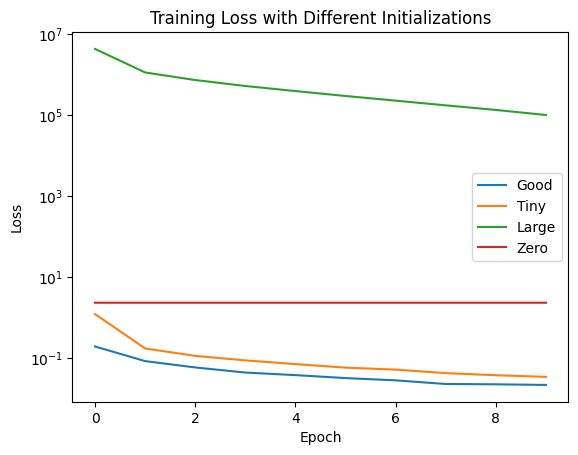

In [21]:
plt.plot(good_loss, label="Good")
plt.plot(tiny_loss, label="Tiny")
plt.plot(large_loss, label="Large")
plt.plot(zero_loss, label="Zero")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Different Initializations")
plt.legend()
plt.show()